In [122]:
import warnings

warnings.filterwarnings("ignore")

In [123]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/andresca94/MasterCard-Stock-Price-Prediction-Using-LSTM-and-GRU/refs/heads/main/Mastercard_stock_history.csv", date_format="Date", index_col="Date")
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2006-05-25,3.748967,4.283869,3.739664,4.279217,395343000,0.0,0.0
2006-05-26,4.307126,4.348058,4.103398,4.179680,103044000,0.0,0.0
2006-05-30,4.183400,4.184330,3.986184,4.093164,49898000,0.0,0.0
2006-05-31,4.125723,4.219679,4.125723,4.180608,30002000,0.0,0.0
2006-06-01,4.179678,4.474572,4.176887,4.419686,62344000,0.0,0.0


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3872 entries, 2006-05-25 to 2021-10-11
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          3872 non-null   float64
 1   High          3872 non-null   float64
 2   Low           3872 non-null   float64
 3   Close         3872 non-null   float64
 4   Volume        3872 non-null   int64  
 5   Dividends     3872 non-null   float64
 6   Stock Splits  3872 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 242.0+ KB


In [125]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,3872.000000,3872.000000,3872.000000,3872.000000,3.872000e+03,3872.000000,3872.000000
mean,104.896814,105.956054,103.769349,104.882714,1.232250e+07,0.002329,0.002583
std,106.245511,107.303589,105.050064,106.168693,1.759665e+07,0.025851,0.160706
min,3.748967,4.102467,3.739664,4.083861,6.411000e+05,0.000000,0.000000
25%,22.347203,22.637997,22.034458,22.300391,3.529475e+06,0.000000,0.000000
50%,70.810079,71.375896,70.224002,70.856083,5.891750e+06,0.000000,0.000000
75%,147.688448,148.645373,146.822013,147.688438,1.319775e+07,0.000000,0.000000
max,392.653890,400.521479,389.747812,394.685730,3.953430e+08,0.440000,10.000000


In [126]:
df.isna().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [127]:
start_date = 2010
end_date = 2013

In [128]:
data = df.loc[f"{start_date}":f"{end_date}","High"]

In [129]:
data

Date
2010-01-04    24.305701
2010-01-05    24.283114
2010-01-06    24.135339
2010-01-07    23.930004
2010-01-08    24.011009
                ...    
2012-12-24    47.051781
2012-12-26    47.022374
2012-12-27    46.730355
2012-12-28    46.331183
2012-12-31    46.641224
Name: High, Length: 754, dtype: float64

In [130]:
data.index

Index(['2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07', '2010-01-08',
       '2010-01-11', '2010-01-12', '2010-01-13', '2010-01-14', '2010-01-15',
       ...
       '2012-12-17', '2012-12-18', '2012-12-19', '2012-12-20', '2012-12-21',
       '2012-12-24', '2012-12-26', '2012-12-27', '2012-12-28', '2012-12-31'],
      dtype='object', name='Date', length=754)

In [131]:
data.values[:10]

array([24.30570068, 24.28311404, 24.13533926, 23.93000448, 24.01100891,
       24.05244564, 23.8245035 , 24.13533371, 24.66280663, 25.04333242])

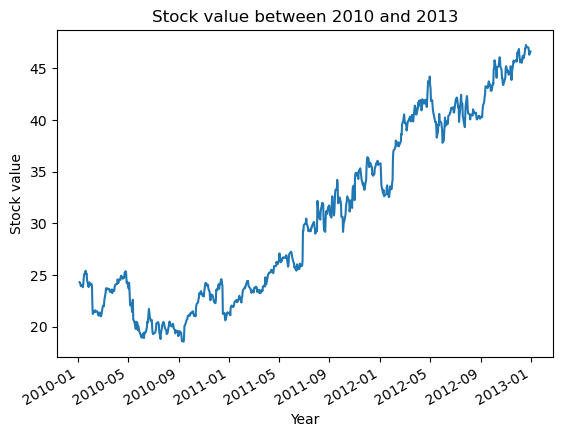

In [132]:
import matplotlib.pyplot as plt

plt.plot(pd.to_datetime(data.index), data.values)
plt.gcf().autofmt_xdate()
plt.title(f"Stock value between {start_date} and {end_date}")
plt.xlabel("Year")
plt.ylabel("Stock value")
plt.show()

In [133]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data.values.reshape(-1, 1))

In [134]:
scaled_data[:3]

array([[-0.71854006],
       [-0.72114437],
       [-0.73818328]])

In [135]:
len(scaled_data)

754

In [136]:
import numpy as np

x = []
y = []
window_size = 60

for i in range(window_size, len(scaled_data)):
    x.append(scaled_data[i - window_size: i, 0])
    y.append(scaled_data[i, 0])

X, Y = np.array(x), np.array(y)

In [137]:
X,Y

(array([[-0.71854006, -0.72114437, -0.73818328, ..., -0.81952836,
         -0.81420626, -0.76435747],
        [-0.72114437, -0.73818328, -0.76185905, ..., -0.81420626,
         -0.76435747, -0.75946981],
        [-0.73818328, -0.76185905, -0.75251897, ..., -0.76435747,
         -0.75946981, -0.74198496],
        ...,
        [ 1.42306368,  1.50609919,  1.4915683 , ...,  1.91115389,
          1.90415677,  1.90076609],
        [ 1.50609919,  1.4915683 ,  1.66506474, ...,  1.90415677,
          1.90076609,  1.86709528],
        [ 1.4915683 ,  1.66506474,  1.66855976, ...,  1.90076609,
          1.86709528,  1.8210695 ]]),
 array([-0.75946981, -0.74198496, -0.73785745, -0.68648743, -0.70060055,
        -0.72505077, -0.69581897, -0.68484402, -0.68984234, -0.64974386,
        -0.64507182, -0.65528635, -0.67908409, -0.6644138 , -0.65930738,
        -0.66832694, -0.61334018, -0.59551875, -0.63279127, -0.72505034,
        -0.71266173, -0.72396447, -0.78927371, -0.72352995, -0.81535258,
        

In [138]:
X.shape

(694, 60)

In [139]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
X.shape

(694, 60, 1)

In [140]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [141]:
len(x_train), len(x_test)

(555, 139)

In [142]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(window_size, 1)))
model.add(Dropout(0.3))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(1))

In [143]:
model.compile(optimizer="adam", loss="mean_squared_error")

In [144]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [145]:
history = model.fit(x_train, y_train, epochs=20)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.4302
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0663
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0412  
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0370
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0329
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0342 
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0331 
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0335
Epoch 9/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0260
Epoch 10/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0313
Epoch 11/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0268 
Epoch 12/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0285
Epoch 13/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0271 
Epoch 14/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0278  
Epoch 15/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0

In [147]:
prediction = model.predict(x_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [148]:
len(prediction)

139

In [149]:
final_prediction = scaler.inverse_transform(prediction.reshape(-1,1))

In [151]:
final_prediction[:5]

array([[32.704967],
       [44.65726 ],
       [23.921665],
       [29.734371],
       [27.348389]], dtype=float32)

In [152]:
y_test_transformed = scaler.inverse_transform(y_test.reshape(-1, 1))

In [153]:
y_test_transformed[:3]

array([[30.63083611],
       [45.7556606 ],
       [25.09685232]])

In [154]:
len(y_test_transformed), len(final_prediction)

(139, 139)

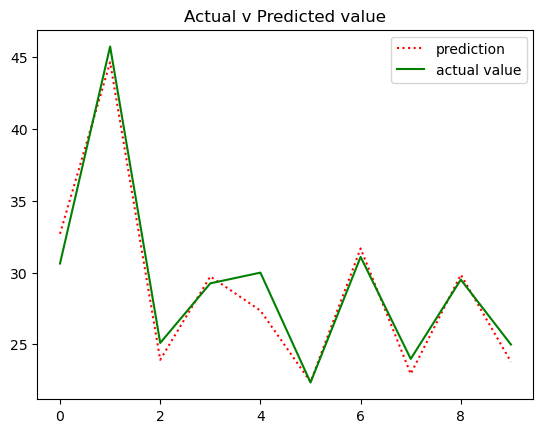

In [180]:
plt.plot(final_prediction[:10], label="prediction", linestyle="dotted", c="red")
plt.plot(y_test_transformed[:10], label="actual value", linestyle="solid", c="green")
plt.title("Actual v Predicted value")
plt.legend()
plt.show()